## Lab 3 DS6021
Ciarra Barnett  


In [77]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm  
import statsmodels.formula.api as smf  


from statsmodels.stats.outliers_influence import (
    variance_inflation_factor,
    OLSInfluence
)

Part 1: 

In [78]:
peng = pd.read_csv("data/penguins.csv").dropna(
    subset=[
        "flipper_length_mm",
        "body_mass_g",
        "bill_length_mm",
        "bill_depth_mm"
    ]
).reset_index(drop=True)

bike = pd.read_csv("data/bike-sharing-daily.csv")

bike["dteday"] = pd.to_datetime(bike["dteday"])

print("Penguins:", peng.shape)
print("Bike data:", bike.shape)

Penguins: (342, 8)
Bike data: (731, 16)


In [79]:
bike_vars = bike [["cnt", "temp","hum", "windspeed"]] 
bike_vars.corr()


,cnt,temp,hum,windspeed
cnt,1.000000,0.627494,-0.100659,-0.234545
temp,0.627494,1.000000,0.126963,-0.157944
hum,-0.100659,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.157944,-0.248489,1.000000


Question 1: I would compare the models using adjusted R^2, VIF ad the nested F-test. I would check for multicollinearity and whther adding more predictors significantly improved the model. I still choose the model with flipper length, bill dpeth and bill length because it explains more variation in body mass. 

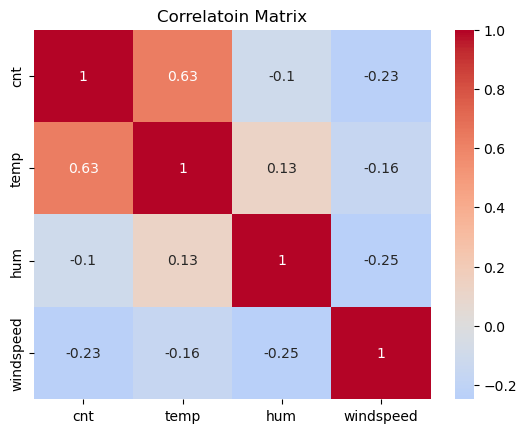

In [80]:
sns.heatmap(
    bike_vars.corr(),
    annot=True, 
    cmap="coolwarm", 
    center=0
) 
plt.title("Correlatoin Matrix")
plt.show()

 
Temperature: 0627 
Humidity: -1.101
Windspeed: -0.235 

2a: 
Temperature has the strongest positive relationship with bike rentals (0.63), while humidity and windspeed have weak negative relationships. Multicollinearity is unlikely to be a major issue.

In [81]:
bike_model = smf.ols(
    "cnt ~ temp + hum + windspeed",
    data=bike
).fit()

print(bike_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     207.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.26e-97
Time:                        23:06:26   Log-Likelihood:                -6343.9
No. Observations:                 731   AIC:                         1.270e+04
Df Residuals:                     727   BIC:                         1.271e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4084.3634    337.862     12.089      0.0

In [82]:
X = bike[["temp", "hum", "windspeed"]]

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,const,41.075299
1,temp,1.034283
2,hum,1.074850
3,windspeed,1.084580


2b 

The VIF values are close to 1, suggesting little multicollinearity. Temperature has a postive relationship with bike rentals, while humidity and windspeed have a negative relatiionships. This makes sense because people are more likely to ride bikes when the weather is warm, less humind and less windy. 

In [83]:
model1 = smf.ols(
    "cnt ~ temp",
    data=bike
).fit()

model2 = smf.ols(
    "cnt ~ temp + hum",
    data=bike
).fit()

model3 = smf.ols(
    "cnt ~ temp + hum + windspeed",
    data=bike
).fit()

sm.stats.anova_lm(model1, model2, model3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,729.0,1.660847e+09,0.0,NaN,NaN,NaN
1,728.0,1.570304e+09,1.0,9.054330e+07,44.569779,4.869005e-11
2,727.0,1.476897e+09,1.0,9.340630e+07,45.979085,2.475445e-11


The nested F-test shows that adding humidity significantly improves Model 1(p<0.0001>). Adding, windspeed also significantly improves Model 2(p<0.001). Both variables help explain the variation in bike rentals. 

2d: I would choose Model 3 because adding humidity and windspeed significantly improves the model. Both nested F-tests have p-values below 0.05, showing that these predictorsn provide useful information for predicting bike rentals. 

## Part 2:  



1. 

In [84]:
peng_sex = peng.dropna(subset=["sex"]).reset_index(drop=True)

print("Original dataset:", peng.shape)
print("New dataset:", peng_sex.shape)

Original dataset: (342, 8)
New dataset: (333, 8)


In [85]:
model_original = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm",
    data=peng
).fit()

print(model_original.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        23:06:26   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6424.7647    561.46

In [86]:
model_new = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm",
    data=peng_sex
).fit()

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     354.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.26e-103
Time:                        23:06:26   Log-Likelihood:                -2459.8
No. Observations:                 333   AIC:                             4928.
Df Residuals:                     329   BIC:                             4943.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6445.4760    566.13

In [87]:
comparison = pd.DataFrame({
    "Model": ["Original", "Missing sex removed"],
    "Observations": [
        model_original.nobs,
        model_new.nobs
    ],
    "R^2": [
        model_original.rsquared,
        model_new.rsquared
    ],
    "Adjusted R^2": [
        model_original.rsquared_adj,
        model_new.rsquared_adj
    ]
})

comparison

,Model,Observations,R^2,Adjusted R^2
0,Original,342.0,0.761470,0.759353
1,Missing sex removed,333.0,0.763937,0.761784


Q1: Removing the 9 penguins with missing sex values did not significantly change the model's results. R^2 increased slightly from 0.762 to 0.764, and the adjusted R^2 remained similar. This suggests that removing these penguins has little effect on the model.

In [88]:
# Flippers only 
model1 = smf.ols(
    "body_mass_g ~ flipper_length_mm",
    data=peng_sex
).fit()
# Additive model
model2 = smf.ols(
    "body_mass_g ~ flipper_length_mm + C(sex)",
    data=peng_sex
).fit()
# Interaction model
model3 = smf.ols(
    "body_mass_g ~ flipper_length_mm * C(sex)",
    data=peng_sex
).fit()

print(model1.summary())
print(model2.summary())
print(model3.summary())

sm.stats.anova_lm(model1, model2, model3)

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.13e-105
Time:                        23:06:26   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5872.0927    310.28

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,331.0,5.121196e+07,0.0,NaN,NaN,NaN
1,330.0,4.179537e+07,1.0,9.416589e+06,74.126700,3.050629e-16
2,329.0,4.179409e+07,1.0,1.286001e+03,0.010123,9.199177e-01


2a: 

I would choose Model 2 because adding sex significantly improves the model (p < 0.001). Adding the interaction term does not significantly improve the model (p = 0.920). This means Model 2 is the simpler model that includes the useful predictors.

In [89]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          3.53e-118
Time:                        23:06:26   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.79

2b: 

Sex improves the predictions of body mass (p<0.001.) Male penguins are roughly 348 grams heavier than female penguins with the same flipper length. Body mass increaded about 47 grams for every flipper length. 

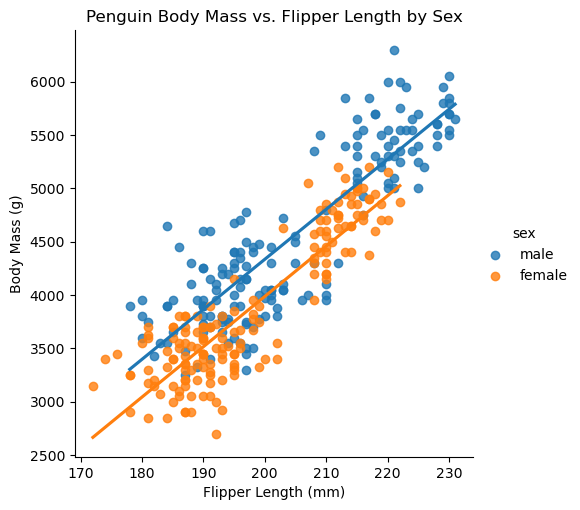

In [90]:
sns.lmplot(
    data=peng_sex,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="sex",
    ci=None
)

plt.title("Penguin Body Mass vs. Flipper Length by Sex")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

2c:

The scatterplot shows that the body mass increases for both male and female penguins. Males usually has higher body mass than the females at the same flipper length. The regression lines have similar slops and that helps support teh additive modeling. 

3

In [91]:

model_add = smf.ols(
    "body_mass_g ~ C(sex) + C(species)",
    data=peng_sex
).fit()

model_int = smf.ols(
    "body_mass_g ~ C(sex) * C(species)",
    data=peng_sex
).fit()

print(model_add.summary())
print(model_int.summary())
sm.stats.anova_lm(model_add, model_int)

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     606.1
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          1.27e-133
Time:                        23:06:26   Log-Likelihood:                -2387.8
No. Observations:                 333   AIC:                             4784.
Df Residuals:                     329   BIC:                             4799.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,329.0,3.297919e+07,0.0,NaN,NaN,NaN
1,327.0,3.130263e+07,2.0,1.676557e+06,8.756997,0.000197


 ### 3a

I would choose the interaction model because the nested F-test
shows that adding the interaction terms significantly improves
the model (p = 0.000197). This means that the difference in body mass between male and female penguins varies depending on the species.

In [92]:
model_int.params 
model_int.params

Intercept                                 3368.835616
C(sex)[T.male]                             674.657534
C(species)[T.Chinstrap]                    158.370266
C(species)[T.Gentoo]                      1310.905763
C(sex)[T.male]:C(species)[T.Chinstrap]    -262.892828
C(sex)[T.male]:C(species)[T.Gentoo]        130.437152
dtype: float64

3b: 

Male penguins ususally weighs more than female penguins, and Gentoo penguins weigh more thsn the Adelie. The interaction terms show the difference in body mass between males and femles. 

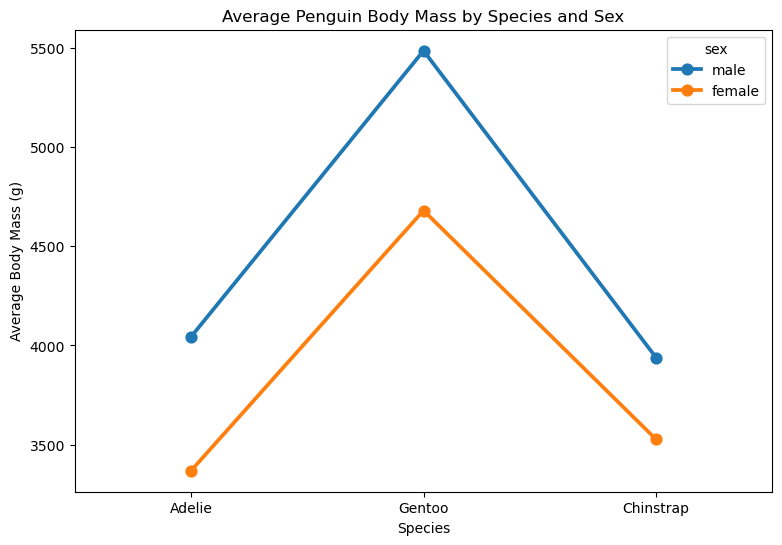

In [93]:
plt.figure(figsize=(9, 6))

sns.pointplot(
    data=peng_sex,
    x="species",
    y="body_mass_g",
    hue="sex",
    errorbar=None
)

plt.title("Average Penguin Body Mass by Species and Sex")
plt.xlabel("Species")
plt.ylabel("Average Body Mass (g)")

plt.show()

3c: 

I created a plor comparing average bodyy mass by sex and species. The plot shows that male and female penguins have different
average body masses, and the size of this difference varies
across species. This supports the interaction model because the relationship
between sex and body mass depends on the penguin species.

4. 


In [94]:

casual_add = smf.ols(
    "casual ~ temp + C(workingday) + hum + windspeed",
    data=bike
).fit()


casual_int = smf.ols(
    "casual ~ temp * C(workingday) + hum + windspeed",
    data=bike
).fit()

print(casual_add.summary())
print(casual_int.summary()) 
sm.stats.anova_lm(casual_add, casual_int)  


print("Additive Adjusted R^2:", casual_add.rsquared_adj)
print("Interaction Adjusted R^2:", casual_int.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:                 casual   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     307.9
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          9.84e-155
Time:                        23:06:26   Log-Likelihood:                -5448.9
No. Observations:                 731   AIC:                         1.091e+04
Df Residuals:                     726   BIC:                         1.093e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1063.5527    101

In [95]:
sm.stats.anova_lm(casual_add, casual_int)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,726.0,1.276423e+08,0.0,NaN,NaN,NaN
1,725.0,1.103186e+08,1.0,1.732378e+07,113.849712,8.681452e-25


4a: 

I would choose the interaction model because it has a higher adjusted R^2 (0.677) than the additive model (0.627). The nested f- test shows that interaction improve the model. This suggests that the relationship between temperature and casual bike rentals differs bwteen working anf non-working days. 

In [96]:

registered_add = smf.ols(
    "registered ~ temp + C(workingday) + hum + windspeed",
    data=bike
).fit()


registered_int = smf.ols(
    "registered ~ temp * C(workingday) + hum + windspeed",
    data=bike
).fit()

print(registered_add.summary())
print(registered_int.summary()) 

sm.stats.anova_lm(registered_add, registered_int) 

print("Additive Adjusted R²:", registered_add.rsquared_adj)
print("Interaction Adjusted R²:", registered_int.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     134.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           5.97e-86
Time:                        23:06:26   Log-Likelihood:                -6208.8
No. Observations:                 731   AIC:                         1.243e+04
Df Residuals:                     726   BIC:                         1.245e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2945.8161    286

4b: 

The interaction model has a higher asjusted R^2 0.424 than the addituve model 0.422. Adding the interaction between temperature and working day slightly improves the prediction of registered bike rentals. 



4c: Temperature affects bike rentals differently depending on user type and working days. The interaction is stronger for casual users. Working days are linked to fewer casual rentals but more registered rentals, thid shows that the two groups have different rental patterns.

4d: 
I built separate models because casual and registered rentals make up the total bike rentals. Using them to predict the total would cause data leakage. Separate models help us understand how temperature and working days affect each group differently.

## Part 3: 

In [97]:


model_original = smf.ols(
    "body_mass_g ~ flipper_length_mm + bill_depth_mm + bill_length_mm",
    data=peng
).fit()

print(model_original.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Sun, 20 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        23:06:26   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -6424.7647    561.46

In [98]:

influence = model_original.get_influence()


peng_influence = pd.DataFrame({
    "actual_body_mass": model_original.model.endog,
    "predicted_body_mass": model_original.fittedvalues,
    "studentized_residual": influence.resid_studentized_external,
    "leverage": influence.hat_matrix_diag,
    "cooks_distance": influence.cooks_distance[0]
})


peng_influence.head(10)

,actual_body_mass,predicted_body_mass,studentized_residual,leverage,cooks_distance
0,3750.0,3211.617868,1.376420,0.008831,0.004209
1,3800.0,3438.564312,0.921907,0.007306,0.001564
2,3250.0,3906.346483,-1.676699,0.004599,0.003230
3,3450.0,3816.889879,-0.938715,0.013330,0.002977
4,3650.0,3702.967340,-0.135413,0.014287,0.000067
5,3625.0,3192.740924,1.104655,0.009992,0.003077
6,4675.0,3933.847733,1.902148,0.011451,0.010398
7,3475.0,3782.009706,-0.786136,0.015675,0.002463
8,4250.0,3706.184442,1.391234,0.010026,0.004887
9,3300.0,3425.474357,-0.319884,0.008505,0.000220


In [99]:
print(peng_influence.shape)

peng_influence.head()

(342, 5)


,actual_body_mass,predicted_body_mass,studentized_residual,leverage,cooks_distance
0,3750.0,3211.617868,1.376420,0.008831,0.004209
1,3800.0,3438.564312,0.921907,0.007306,0.001564
2,3250.0,3906.346483,-1.676699,0.004599,0.003230
3,3450.0,3816.889879,-0.938715,0.013330,0.002977
4,3650.0,3702.967340,-0.135413,0.014287,0.000067


In [100]:
n = 342 
p = 3

resid_cut = 3 
lev_cut = 2 * (p + 1) / n
cook_cut = 4 / n

print("Studentized residual cutoff:", resid_cut)
print("Leverage cutoff:", round(lev_cut, 4))
print("Cook's distance cutoff:", round(cook_cut, 4))

Studentized residual cutoff: 3
Leverage cutoff: 0.0234
Cook's distance cutoff: 0.0117


In [101]:

print(
    "Studentized residual outliers:",
    (peng_influence["studentized_residual"].abs() > resid_cut).sum()
)
print(
    "High leverage:",
    (peng_influence["leverage"] > lev_cut).sum()
)
print(
    "High Cook's distance:",
    (peng_influence["cooks_distance"] > cook_cut).sum()
)

Studentized residual outliers: 1
High leverage: 10
High Cook's distance: 13


In [102]:
peng_influence["sex"] = peng["sex"].to_numpy()

missing_sex = peng_influence[
    peng_influence["sex"].isna()
].copy()

missing_sex

,actual_body_mass,predicted_body_mass,studentized_residual,leverage,cooks_distance,sex
7,3475.0,3782.009706,-0.786136,0.015675,0.002463,NaN
8,4250.0,3706.184442,1.391234,0.010026,0.004887,NaN
9,3300.0,3425.474357,-0.319884,0.008505,0.000220,NaN
10,3700.0,3127.868934,1.465755,0.012216,0.006620,NaN
46,2975.0,3108.430419,-0.340460,0.010170,0.000299,NaN
177,4100.0,4905.296510,-2.067466,0.010211,0.010919,NaN
217,4650.0,4813.838115,-0.417769,0.008677,0.000383,NaN
255,4725.0,4906.924841,-0.464586,0.011531,0.000631,NaN
267,4875.0,4983.635078,-0.277006,0.008949,0.000174,NaN


In [103]:

missing_sex["outlier"] = (
    missing_sex["studentized_residual"].abs() > resid_cut
)

missing_sex["high_leverage"] = (
    missing_sex["leverage"] > lev_cut
)

missing_sex["high_cooks_distance"] = (
    missing_sex["cooks_distance"] > cook_cut
)

missing_sex

,actual_body_mass,predicted_body_mass,studentized_residual,leverage,cooks_distance,sex,outlier,high_leverage,high_cooks_distance
7,3475.0,3782.009706,-0.786136,0.015675,0.002463,NaN,False,False,False
8,4250.0,3706.184442,1.391234,0.010026,0.004887,NaN,False,False,False
9,3300.0,3425.474357,-0.319884,0.008505,0.000220,NaN,False,False,False
10,3700.0,3127.868934,1.465755,0.012216,0.006620,NaN,False,False,False
46,2975.0,3108.430419,-0.340460,0.010170,0.000299,NaN,False,False,False
177,4100.0,4905.296510,-2.067466,0.010211,0.010919,NaN,False,False,False
217,4650.0,4813.838115,-0.417769,0.008677,0.000383,NaN,False,False,False
255,4725.0,4906.924841,-0.464586,0.011531,0.000631,NaN,False,False,False
267,4875.0,4983.635078,-0.277006,0.008949,0.000174,NaN,False,False,False


In [104]:
print("Missing-sex penguins:", len(missing_sex))

print("Outliers:", missing_sex["outlier"].sum())

print("High leverage:", missing_sex["high_leverage"].sum())

print(
    "High Cook's distance:",
    missing_sex["high_cooks_distance"].sum()
)

Missing-sex penguins: 9
Outliers: 0
High leverage: 0
High Cook's distance: 0


1b: 

Out of 342 penguins, 1 exceeded studentized residual cutoff 3, 10 exceeded the leveraged cutoff 0.0234, and 13 exceeded the cooks distancce 0.0117. The 9 penguins with missing sex values exceeded any of these cutofs


1c: 

None of the 9 penguins with missing sex values exceeded the cutoffs for studentized residuals, leverage  or cooks distance. These penguins are unusual or influential in th orginial model. I would keep them in models that do not use sex. 

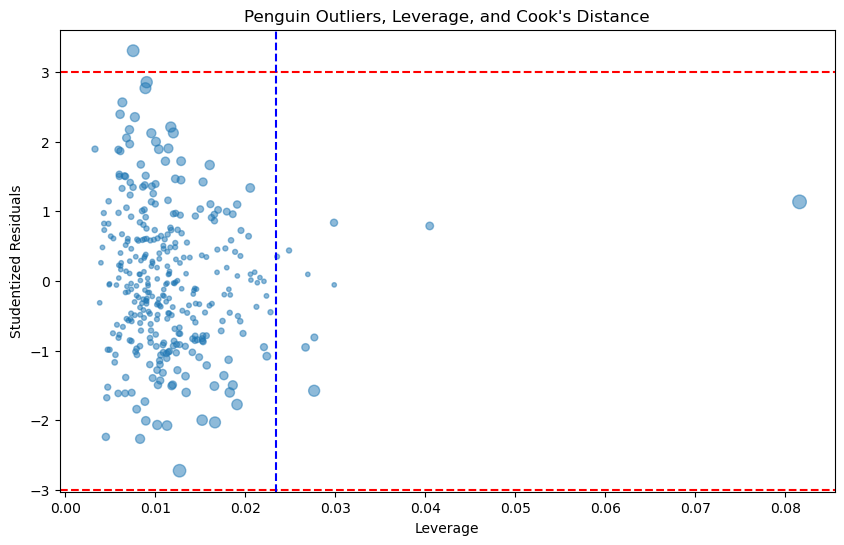

In [105]:

plt.figure(figsize=(10, 6))

plt.scatter(
    peng_influence["leverage"],
    peng_influence["studentized_residual"],
    s=peng_influence["cooks_distance"] * 3000 + 10,
    alpha=0.5
)

plt.axhline(3, color="red", linestyle="--")
plt.axhline(-3, color="red", linestyle="--")

plt.axvline(lev_cut, color="blue", linestyle="--")

plt.xlabel("Leverage")
plt.ylabel("Studentized Residuals")

plt.title("Penguin Outliers, Leverage, and Cook's Distance")

plt.show()

1d: 

Most penguins fall within the residual and leverage cutoffs. However, one penguin had a high residual, and ten had high leverage.


2. 


In [106]:

bike["dteday"] = pd.to_datetime(bike["dteday"])

bike_original = smf.ols(
    "cnt ~ temp + C(workingday) + hum + windspeed",
    data=bike
).fit()

bike_no_sandy = bike[
    bike["dteday"] != "2012-10-29"
].copy()

model_no_sandy = smf.ols(
    "cnt ~ temp + C(workingday) + hum + windspeed",
    data=bike_no_sandy
).fit()


bike_no_march = bike[
    bike["dteday"] != "2012-03-17"
].copy()

model_no_march = smf.ols(
    "cnt ~ temp + C(workingday) + hum + windspeed",
    data=bike_no_march
).fit()

comparison = pd.DataFrame({
    "Original Model": bike_original.params,
    "Without Sandy": model_no_sandy.params,
    "Without March 17": model_no_march.params
})

comparison["Sandy Change"] = (
    comparison["Without Sandy"] - comparison["Original Model"]
)
comparison["March 17 Change"] = (
    comparison["Without March 17"] - comparison["Original Model"]
)
print("Coefficient Comparison:")
display(comparison.round(2))

print("\nAdjusted R-squared Comparison:")

print(
    "Original Model:",
    round(bike_original.rsquared_adj, 4)
)
print(
    "Without Sandy:",
    round(model_no_sandy.rsquared_adj, 4)
)
print(
    "Without March 17:",
    round(model_no_march.rsquared_adj, 4)
)

Coefficient Comparison:


,Original Model,Without Sandy,Without March 17,Sandy Change,March 17 Change
Intercept,4009.37,3948.37,3998.68,-61.00,-10.68
C(workingday)[T.1],125.80,131.05,140.53,5.24,14.72
temp,6609.71,6605.48,6610.95,-4.23,1.24
hum,-3106.83,-3044.94,-3129.92,61.89,-23.08
windspeed,-4801.70,-4674.59,-4749.53,127.11,52.17



Adjusted R-squared Comparison:
Original Model: 0.4588
Without Sandy: 0.4573
Without March 17: 0.4607


Removing October 29, 2012 (Hurricane Sandy)  changed the coefficients and decreased adjusted R^2 from 0.4588 to 0.4573. Removing March 17, 2012 slightly changed the coefficients and increased adjusted R^2 from 0.4588 to 0.4607. I would keep both dates because removing them does not significantly improve the model

Part 5: 

After reading the articles provided I was able to understand how feature transformations can improve a model performance. Log transformations can make relationships more linear, while standardization and normalization adjust the scale of variables. I learned that choosing the right transformation can improve model accuracy. I enjoyed connecting what we've learned/discussed i class to this. 